In [1]:
import copernicusmarine
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm 
import numpy as np
import pandas as pd
import cartopy.crs as ccrs

In [2]:
# # Set parameters
# data_request = {
#    "dataset_id_plume" : "cmems_mod_glo_phy_my_0.083deg_P1D-m",
#    "dataset_version": "202311",
#    "longitude" : [-75, -35], 
#    "latitude" : [-10, 30],
#    "time" : ["1993-01-01", "2021-06-30"],
#    "variables" : ["vo","uo"]
# }

# # Load xarray dataset
# ds = copernicusmarine.open_dataset(
#     dataset_id = data_request["dataset_id_plume"],
#     minimum_longitude = data_request["longitude"][0],
#     maximum_longitude = data_request["longitude"][1],
#     minimum_latitude = data_request["latitude"][0],
#     maximum_latitude = data_request["latitude"][1],
#     start_datetime = data_request["time"][0],
#     end_datetime = data_request["time"][1],
#     minimum_depth=0.49402499198913574,
#     maximum_depth=0.49402499198913574,
#     variables = data_request["variables"],
#     username = 'dbarreto',
#     password = 'DoNuT_120197',
#     chunk_size_limit = -1
# )

In [3]:
data_request = {
   "dataset_id_plume" : "cmems_mod_glo_phy_my_0.083deg_P1D-m",
   "dataset_version": "202311",
   "longitude" : [-4, 12], 
   "latitude" : [50, 63],
   "time" : ["2024-07-30", "2024-07-30"],
   "variables" : ["so","thetao"]
}

# Load xarray dataset
ds = copernicusmarine.open_dataset(
    dataset_id = data_request["dataset_id_plume"],
    minimum_longitude = data_request["longitude"][0],
    maximum_longitude = data_request["longitude"][1],
    minimum_latitude = data_request["latitude"][0],
    maximum_latitude = data_request["latitude"][1],
    start_datetime = data_request["time"][0],
    end_datetime = data_request["time"][1],
    minimum_depth=0.49402499198913574,
    maximum_depth=0.49402499198913574,
    variables = data_request["variables"],
    username = 'alizarbe',
    password = 'DoNuT_120197',
    chunk_size_limit = -1
)

INFO - 2026-03-26T18:35:24Z - Selected dataset version: "202311"
INFO - 2026-03-26T18:35:24Z - Selected dataset part: "default"


In [4]:
ds = ds.compute()
ds

<xarray.Dataset> Size: 486kB
Dimensions:    (depth: 1, latitude: 157, longitude: 193, time: 1)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 628B 50.0 50.08 50.17 ... 62.83 62.92 63.0
  * longitude  (longitude) float32 772B -4.0 -3.917 -3.833 ... 11.83 11.92 12.0
  * time       (time) datetime64[ns] 8B 2024-07-30
Data variables:
    so         (time, depth, latitude, longitude) float64 242kB 34.75 ... nan
    thetao     (time, depth, latitude, longitude) float64 242kB 17.67 ... nan
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.3.0

In [5]:
# fig,ax = plt.subplots(2,1,figsize=(10,5))
# ds.thetao.mean(dim=('longitude','latitude')).plot(ax=ax[0])
# ds.so.mean(dim=('longitude','latitude')).plot(ax=ax[1])

In [6]:
# ds.thetao.mean(dim=('longitude','latitude')).to_pandas().describe()

In [7]:
# ds.so.mean(dim=('longitude','latitude')).to_pandas().describe()

In [8]:
path_SOCAT = '/Users/dlizarbe/Documents/SOLAS_summerschool/Teaching/Notebooks/FalMooring-InSituData-AirSeaGasFluxes/data_from_SOCATv2025/'

In [9]:
SOCAT = xr.open_dataset(path_SOCAT+'data_from_SOCATv2025.nc').compute()
SOCAT

<xarray.Dataset> Size: 530MB
Dimensions:                                    (N_STATIONS: 724068, N_SAMPLES: 1)
Dimensions without coordinates: N_STATIONS, N_SAMPLES
Data variables: (12/38)
    cruise_id                                  (N_STATIONS) |S12 9MB b'069920...
    station_id                                 (N_STATIONS) float64 6MB 3.365...
    station_type                               (N_STATIONS) |S1 724kB b'B' .....
    longitude                                  (N_STATIONS) float32 3MB 357.8...
    latitude                                   (N_STATIONS) float32 3MB 59.39...
    ETOPO2_Depth                               (N_STATIONS) float32 3MB 58.0 ...
    ...                                         ...
    NCEP_NCAR_Sea_Level_Pressure               (N_STATIONS, N_SAMPLES) float32 3MB ...
    NCEP_NCAR_Sea_Level_Pressure_qc            (N_STATIONS, N_SAMPLES) float32 3MB ...
    Pressure_at_Equilibrator                   (N_STATIONS, N_SAMPLES) float32 3MB ...
    Pressure_at_Equilibrator_qc                (N_STATIONS, N_SAMPLES) float32 3MB ...
    Water_Temperature_at_Equilibrator          (N_STATIONS, N_SAMPLES) float32 3MB ...
    Water_Temperature_at_Equilibrator_qc       (N_STATIONS, N_SAMPLES) float32 3MB ...
Attributes:
    Conventions:         CF-1.7
    comment:             ODV NetCDF Export File V2.0
    Creator:             rschlitz@awi-009603
    CreateTime:          2026-03-25T15:34:49
    Software:            Web Ocean Data View 5.8.5.1 - web_server: 46 - 64 bi...
    source:              /srv/data/webodv-explore/data/ocean/carbon/socat/SOC...
    SourceLastModified:  2025-06-02T15:22:00
    DataField:           GeneralField
    DataType:            GeneralType
    Description:         Global fCO2 dataset containing 41.3 million surface ...

In [10]:
SOCAT["longitude"] = ((SOCAT.longitude + 180) % 360) - 180

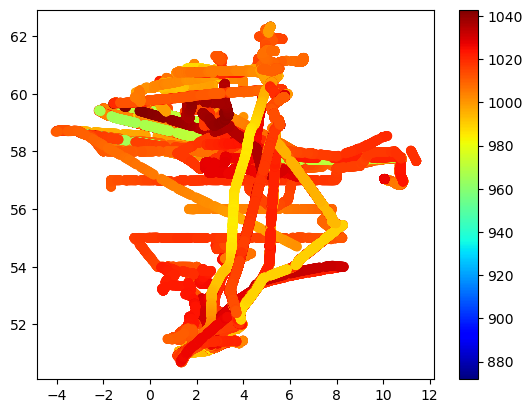

In [11]:
plt.scatter(SOCAT.longitude,SOCAT.latitude,c=SOCAT.Atmospheric_Pressure,cmap='jet')
plt.colorbar()
plt.show()

In [12]:
# SOCAT.sel(date_time = slice('2024-01','2024-12'))
SOCAT = SOCAT.set_coords("date_time")
# SOCAT.sel(date_time = slice('2024-01','2024-12'))
SOCAT

<xarray.Dataset> Size: 530MB
Dimensions:                                    (N_STATIONS: 724068, N_SAMPLES: 1)
Coordinates:
    date_time                                  (N_STATIONS) datetime64[ns] 6MB ...
Dimensions without coordinates: N_STATIONS, N_SAMPLES
Data variables: (12/37)
    cruise_id                                  (N_STATIONS) |S12 9MB b'069920...
    station_id                                 (N_STATIONS) float64 6MB 3.365...
    station_type                               (N_STATIONS) |S1 724kB b'B' .....
    longitude                                  (N_STATIONS) float32 3MB -2.24...
    latitude                                   (N_STATIONS) float32 3MB 59.39...
    ETOPO2_Depth                               (N_STATIONS) float32 3MB 58.0 ...
    ...                                         ...
    NCEP_NCAR_Sea_Level_Pressure               (N_STATIONS, N_SAMPLES) float32 3MB ...
    NCEP_NCAR_Sea_Level_Pressure_qc            (N_STATIONS, N_SAMPLES) float32 3MB ...
    Pressure_at_Equilibrator                   (N_STATIONS, N_SAMPLES) float32 3MB ...
    Pressure_at_Equilibrator_qc                (N_STATIONS, N_SAMPLES) float32 3MB ...
    Water_Temperature_at_Equilibrator          (N_STATIONS, N_SAMPLES) float32 3MB ...
    Water_Temperature_at_Equilibrator_qc       (N_STATIONS, N_SAMPLES) float32 3MB ...
Attributes:
    Conventions:         CF-1.7
    comment:             ODV NetCDF Export File V2.0
    Creator:             rschlitz@awi-009603
    CreateTime:          2026-03-25T15:34:49
    Software:            Web Ocean Data View 5.8.5.1 - web_server: 46 - 64 bi...
    source:              /srv/data/webodv-explore/data/ocean/carbon/socat/SOC...
    SourceLastModified:  2025-06-02T15:22:00
    DataField:           GeneralField
    DataType:            GeneralType
    Description:         Global fCO2 dataset containing 41.3 million surface ...

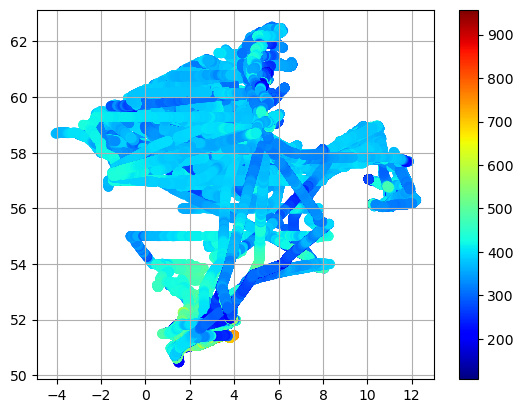

In [13]:
plt.scatter(SOCAT.longitude,SOCAT.latitude,c=SOCAT.fCO2_recomputed_,cmap='jet')
plt.colorbar()
plt.grid(True)

## Following Simple Method (Weiss 1974)

- fCO2 to pCO2

In [14]:
import numpy as np

def fco2_to_pco2(fco2, temp_c, salinity):
    """
    Convert fCO2 to pCO2
    
    Parameters:
    -----------
    fco2 : float or array
        Fugacity of CO2 (μatm)
    temp_c : float or array
        Temperature (°C)
    salinity : float or array
        Salinity (PSU)
    
    Returns:
    --------
    pco2 : float or array
        Partial pressure of CO2 (μatm)
    """
    
    # Convert temperature to Kelvin
    temp_k = temp_c + 273.15
    
    # Weiss (1974) coefficients for fugacity coefficient
    # B = second virial coefficient
    B = -1636.75 + 12.0408 * temp_c - 0.0327957 * temp_c**2
    
    # Pressure correction (assuming 1 atm = 1013.25 hPa at sea surface)
    P = 1.01325  # pressure in bar (1 atm)
    
    # Gas constant
    R = 83.14472  # cm³·bar/(mol·K)
    
    # Fugacity coefficient
    exp_arg = (B * P) / (R * temp_k)
    fugacity_coeff = np.exp(exp_arg)
    
    # Convert fCO2 to pCO2
    pco2 = fco2 / fugacity_coeff
    
    return pco2


# Example usage:
fco2_value = 390.0  # μatm
temp = 10.0  # °C
sal = 35.0  # PSU

pco2_value = fco2_to_pco2(fco2_value, temp, sal)
print(f"fCO2 = {fco2_value} μatm → pCO2 = {pco2_value:.2f} μatm")
# Output: fCO2 = 390.0 μatm → pCO2 = 391.55 μatm

fCO2 = 390.0 μatm → pCO2 = 416.36 μatm


In [15]:
pco2_value = fco2_to_pco2(SOCAT.fCO2_recomputed_, SOCAT.Water_Temperature, SOCAT.Salinity)
pco2_value

<xarray.DataArray (N_STATIONS: 724068, N_SAMPLES: 1)> Size: 3MB
array([[413.21524],
       [413.223  ],
       [413.3422 ],
       ...,
       [437.1731 ],
       [438.07138],
       [440.60617]], shape=(724068, 1), dtype=float32)
Coordinates:
    date_time  (N_STATIONS) datetime64[ns] 6MB 2023-05-27T21:26:29.999995744 ...
Dimensions without coordinates: N_STATIONS, N_SAMPLES

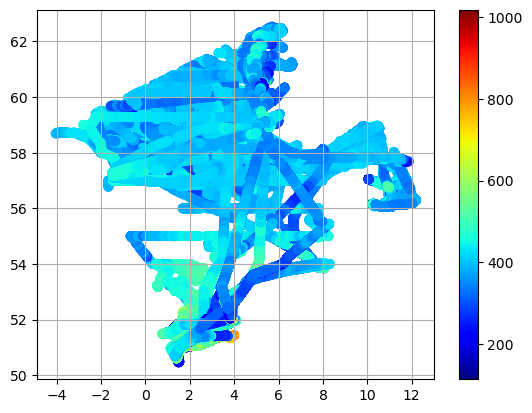

In [16]:
plt.scatter(SOCAT.longitude,SOCAT.latitude,c=pco2_value,cmap='jet')
plt.colorbar()
plt.grid(True)

In [17]:
print(SOCAT.longitude.data.min())
print(SOCAT.longitude.data.max())
print(SOCAT.latitude.data.min())
print(SOCAT.latitude.data.max())

-4.0531006
12.199997
50.45932
62.538


## Linear Interpolation

In [18]:
from scipy.interpolate import griddata

In [19]:
lon = SOCAT.longitude.data.flatten()
lat = SOCAT.latitude.data.flatten()
pco2 = pco2_value.data.flatten()
pco2

array([413.21524, 413.223  , 413.3422 , ..., 437.1731 , 438.07138,
       440.60617], shape=(724068,), dtype=float32)

In [20]:
# Interpolate
valid = ~np.isnan(pco2)
lon_grid, lat_grid = np.meshgrid(
    np.linspace(lon.min(), lon.max(), 193), #16
    np.linspace(lat.min(), lat.max(), 157) #12
)
pco2_grid = griddata(
    np.column_stack([lon[valid], lat[valid]]),
    pco2[valid],
    np.column_stack([lon_grid.ravel(), lat_grid.ravel()]),
    method='linear'
).reshape(lon_grid.shape)

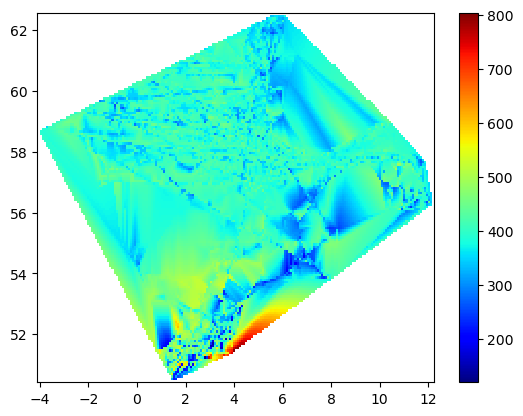

In [21]:
plt.pcolormesh(lon_grid,lat_grid,pco2_grid,cmap='jet')
plt.colorbar()

In [24]:
# plt.pcolormesh(lon,lat,pco2_final)
# Step 5: Calculate pCO2_SST
pco2_sst = pco2 * np.exp(0.0423 * (20.0 - SOCAT.Water_Temperature.data.flatten()))
pco2_sst

array([640.2497 , 640.6681 , 641.20544, ..., 540.4148 , 538.62384,
       543.0252 ], shape=(724068,), dtype=float32)

In [ ]:
# Interpolate
valid = ~np.isnan(pco2)
lon_grid, lat_grid = np.meshgrid(
    np.linspace(lon.min(), lon.max(), 193),#16*12
    np.linspace(lat.min(), lat.max(), 157) #12*12
)
pco2_sst_grid = griddata(
    np.column_stack([lon[valid], lat[valid]]),
    pco2_sst[valid],
    np.column_stack([lon_grid.ravel(), lat_grid.ravel()]),
    method='linear'
).reshape(lon_grid.shape)

In [ ]:
plt.pcolormesh(lon_grid,lat_grid,pco2_sst_grid,cmap='jet')
plt.colorbar()

In [ ]:
pco2_air_noaa_2024 = 428.0

In [ ]:
ds = ds.drop_vars(['depth','time'])
ds

In [ ]:
ds = ds.isel(time=0,depth=0)
ds

In [ ]:
# pco2_air_noaa_2024 = 428.0
pco2_air_noaa_2024 = np.ones([157,193])* 428.0
pco2_air_noaa_2024

In [ ]:
data = xr.Dataset(
    data_vars = {
        'pco2_sst': (('latitude','longitude'),pco2_sst_grid),
        'pco2sw_corr_split': (('latitude','longitude'),pco2_grid),
        'salinity':(('latitude','longitude'),ds.so.data),
        'sstskin_c':(('latitude','longitude'),ds.thetao.data),
        'sstskin_k':(('latitude','longitude'),ds.thetao.data + 273.15),
        'pco2_air_noaa_2024':(('latitude','longitude'),pco2_air_noaa_2024),
        
    },
    coords = {
        'latitude':ds.latitude.data,
        'longitude':ds.longitude.data,
            },
)
data

## Atmospheric Pressure

In [ ]:
path_atm='/Users/dlizarbe/Documents/SOLAS_summerschool/SML/'

In [ ]:
atm = xr.open_dataset(path_atm+'atm_pressure.nc').compute()
atm

In [ ]:
atm.sp.mean(dim='valid_time').plot()

In [ ]:
winds = xr.open_dataset(path_atm+'wind_speed_FINAL.nc')
winds

In [ ]:
winds.ws10.mean(dim='valid_time').plot()

In [ ]:
print(winds.longitude.min().data)
print(winds.latitude.min().data)

print(winds.longitude.max().data)
print(winds.latitude.max().data)

## 2D interpolator

In [ ]:
lon_fine = np.linspace(winds.longitude.min().data, winds.longitude.max().data, 193)
lat_fine = np.linspace(winds.latitude.min().data, winds.latitude.max().data, 157)
lon_grid_fine, lat_grid_fine = np.meshgrid(lon_fine, lat_fine)

In [ ]:
# Extract the original coarse grid (lon=40, lat=35)
lon_coarse = winds.longitude.values.flatten()
lat_coarse = winds.latitude.values.flatten()
lon_grid_coarse, lat_grid_coarse = np.meshgrid(lon_coarse, lat_coarse)

# Step 3: Initialize an empty array to store the interpolated data
winds_speed = np.zeros((157, 193))
atm_press = np.zeros((157, 193))

# Flatten the coarse grid coordinates and data for interpolation
coords_coarse = np.column_stack((lon_grid_coarse.flatten(), lat_grid_coarse.flatten()))
## winds flat
windsflat = winds.ws10.mean(dim='valid_time').data.flatten()

##atmosphere flat 
atmflat = atm.sp.mean(dim='valid_time').data.flatten()


# Flatten the target fine grid coordinates
coords_fine = np.column_stack((lon_grid_fine.flatten(), lat_grid_fine.flatten()))

# Cubic interpolation of Winds
data_winds = griddata(
    coords_coarse,  # Original coordinates (shape: (40*35, 2))
    windsflat,  # Original data (shape: (40*35,))
    coords_fine,  # Target coordinates (shape: (602*542, 2))
    method='cubic'  # or 'linear' for faster results
)

# Cubic interpolation of Winds
data_atm = griddata(
    coords_coarse,  # Original coordinates (shape: (40*35, 2))
    atmflat,  # Original data (shape: (40*35,))
    coords_fine,  # Target coordinates (shape: (602*542, 2))
    method='cubic'  # or 'linear' for faster results
)

winds_speed[:, :] = data_winds.reshape((157, 193))
atm_press[:, :] = data_atm.reshape((157, 193))

In [ ]:
winds_speed

In [ ]:
atm_press

## Create the dataset

In [ ]:
data = xr.Dataset(
    data_vars = {
        'pco2_sst': (('time','latitude','longitude'),pco2_sst_grid),
        'pco2sw_corr_split': (('time','latitude','longitude'),pco2_grid),
        'salinity':(('time','latitude','longitude'),ds.so.data),
        'sstskin_c':(('time','latitude','longitude'),ds.thetao.data),
        'sstskin_k':(('time','latitude','longitude'),ds.thetao.data + 273.15),
        'pco2_air_noaa_2024':(('time','latitude','longitude'),pco2_air_noaa_2024),
        'windu10':(('time','latitude','longitude'),winds_speed),
        'windu10_moment2':(('time','latitude','longitude'),winds_speed**2),
        'pressure_met':(('time','latitude','longitude'),atm_press),
    },
    coords = {
        'latitude':ds.latitude.data,
        'longitude':ds.longitude.data,
        
            },
)
data

In [ ]:
data.pressure_met.plot(robust=True)

In [ ]:
data.to_netcdf('/Users/dlizarbe/Documents/SOLAS_summerschool/SML/dataset_SML.nc')

In [ ]:
# # U interpolated data
# w10 = xr.DataArray(
#     data_winds,
#     dims=('latitude', 'longitude'),
#     coords={
#         'latitude': lat_fine,
#         'longitude': lon_fine
#     }
# )
# w10

